# Hypothesis 1: Sale price varies by period of the year
**Research Question:** Does the timing of the sale affect price?
This analysis looks at average price by month, both for the full dataset 
and specifically for middle-class zipcodes, since that is Bonnie's market 
segment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_middle_class = pd.read_pickle("data/middle_class_zip_pps.pkl")

In [2]:
df_middle_class.columns.tolist()

['id',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'date',
 'price',
 'price_per_sqft',
 'zip_tier_pps',
 'sqft_bucket']

In [3]:
df_middle_class["date"] = pd.to_datetime(df_middle_class["date"], format="%Y-%m-%d")
df_middle_class["sale_month"] = df_middle_class["date"].dt.month

## Average price by month (middle-class zipcodes)

Now we repeat the same calculation, but only using houses in middle-class 
zipcodes, since that is Bonnie's market segment.

In [4]:
avg_price_by_month_middle = df_middle_class.groupby("sale_month")["price"].mean().sort_values(ascending=False)

In [5]:
df_middle_class[df_middle_class["sale_month"] == 1].shape[0]

359

In [6]:
df_middle_class.groupby("sale_month").size().sort_index()

sale_month
1     359
2     418
3     609
4     800
5     862
6     773
7     810
8     700
9     614
10    633
11    492
12    534
dtype: int64

## Highest price month 
A quick way to check the exact month and value with the highest average price

In [7]:
print(f"Highest price month: {avg_price_by_month_middle.idxmax()}")
print(f"Highest price value: {avg_price_by_month_middle.max():,.0f}")

Highest price month: 4
Highest price value: 555,564


In [8]:
avg_price_by_month_middle.max()

np.float64(555563.56375)

In [9]:
avg_price_by_month_middle.idxmax()

np.int32(4)

In [10]:
avg_price_by_month_middle.sort_values(ascending=False)

sale_month
4     555563.563750
6     539496.363519
3     531845.118227
7     526162.229630
8     525988.488571
11    525793.436992
10    520017.756714
9     517699.431596
5     516913.276102
1     516352.295265
12    515480.867041
2     510907.698565
Name: price, dtype: float64

April still has the highest price. But the lowest-price month changes — 
February in the full dataset, September in middle-class zipcodes. This 
shows the pattern is not the same for every segment.

## How big is the price difference?

Now let's check how much higher April is compared to the lowest month.

In [11]:
price_difference_middle = avg_price_by_month_middle.max() - avg_price_by_month_middle.min()
price_percentage_middle = (price_difference_middle / avg_price_by_month_middle.min()) * 100
print(price_difference_middle, price_percentage_middle)

44655.8651854067 8.7404956532987


## Chart: price by month (middle-class zipcodes)

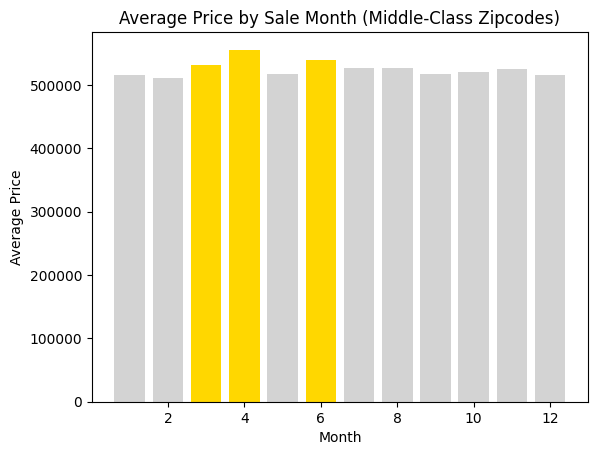

In [12]:
highlight_colour = "#FFD700"
default_colour = "#D3D3D3"

bar_colours = [highlight_colour if (month == 4 or month == 6 or month == 3) else default_colour for month in avg_price_by_month_middle.sort_index().index]

fig, ax = plt.subplots()
ax.bar(avg_price_by_month_middle.sort_index().index, avg_price_by_month_middle.sort_index().values, color=bar_colours)
ax.set_title("Average Price by Sale Month (Middle-Class Zipcodes)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price")
plt.show()

## Chart: price vs. realistic timing for Bonnie

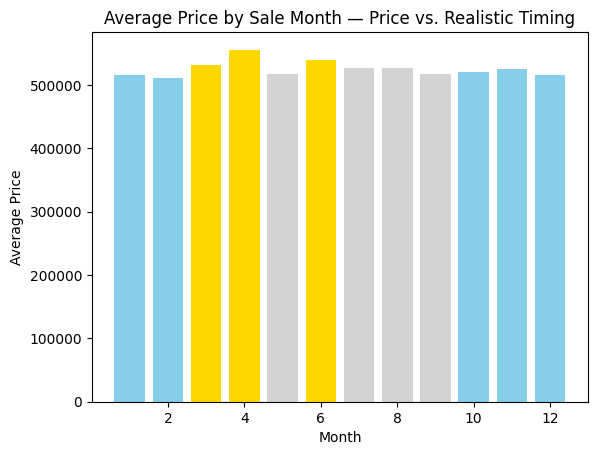

In [13]:
highlight_colour = "#FFD700"
default_colour = "#D3D3D3"
range_colour = "#87CEEB"
overlap_colour = "#90EE90"

top_3_months = [4, 6, 3]
bonnie_range = [10, 11, 12, 1, 2]

def get_colour(month):
    if month in top_3_months and month in bonnie_range:
        return overlap_colour
    elif month in top_3_months:
        return highlight_colour
    elif month in bonnie_range:
        return range_colour
    else:
        return default_colour

bar_colours = [get_colour(month) for month in avg_price_by_month_middle.sort_index().index]

fig, ax = plt.subplots()
ax.bar(avg_price_by_month_middle.sort_index().index, avg_price_by_month_middle.sort_index().values, color=bar_colours)
ax.set_title("Average Price by Sale Month — Price vs. Realistic Timing")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price")
plt.show()

Since Bonnie wants to sell soon, we also looked at a realistic 3-6 month 
window from now (October to February). None of the overall top-3 months 
fall within that window, but prices within the window are still 
reasonably close to the yearly average.

---
## Additional exploration

## Number of sales by month

In [14]:
sales_count_by_month = df_middle_class.groupby("sale_month")["price"].count().sort_index()

How much does the number of sales change by month?


In [15]:
sales_difference = sales_count_by_month.max() - sales_count_by_month.min()
sales_percentage = (sales_difference / sales_count_by_month.min()) * 100
print(sales_difference, sales_percentage)

503 140.11142061281336


Average price only changes a little by month (about 9%). But the number 
of houses sold changes a lot, May had 140% more sales than January. 
Timing seems to matter more for market activity than for price.

## Chart: number of sales by month

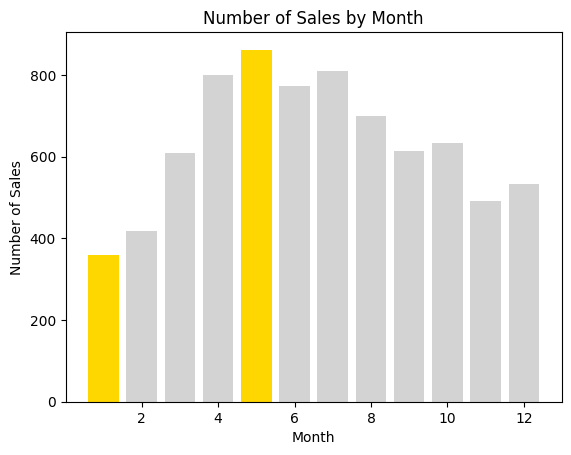

In [16]:
highlight_colour = "#FFD700"
default_colour = "#D3D3D3"

bar_colours = [highlight_colour if (month == 1 or month == 5) else default_colour for month in sales_count_by_month.index]

fig, ax = plt.subplots()
ax.bar(sales_count_by_month.index, sales_count_by_month.values, color=bar_colours)
ax.set_title("Number of Sales by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Sales")
plt.show()

The number of house sales changes a lot by month. It's highest in May 
and lowest in January. This pattern is much stronger than the one we 
saw with price.